# Análise de Sentimento — NPS Swift

Notebook separado a partir de `NPS_Swift.ipynb`. Depende de `data/base_final.csv`, gerado pelo notebook de pré-processamento. A última checagem usa `data/amostra_para_anotacao.csv` quando ela já tiver sido gerada na etapa de clusterização.


<div style="background:linear-gradient(90deg,#E24307 0%,#ffefea 100%);border-left:6px solid #7e2200;color:white;padding:14px 22px;border-radius:8px;font-family:'Segoe UI',sans-serif;font-size:18px;font-weight:bold;letter-spacing:0.5px;margin:16px 0 6px 0;box-shadow:0px 2px 6px rgba(226,67,7,0.3);">PARTE 4 — TÓPICO 3: DEFINIÇÃO DA ANÁLISE DE SENTIMENTO</div>

<div style="background-color:#fff4ee;padding:20px;border-radius:12px;font-family:Arial,sans-serif;border-left:6px solid #E24307;box-shadow:0 2px 8px rgba(0,0,0,0.08);">
  <h2 style="color:#E24307;margin:0;font-size:24px;">0. Importações e Configurações</h2>
</div>

In [1]:
import os
os.environ.setdefault('MPLCONFIGDIR', os.path.abspath('.matplotlib-cache'))
os.environ.setdefault('XDG_CACHE_HOME', os.path.abspath('.cache'))

import warnings
warnings.filterwarnings('ignore')

import re
import os
from pathlib import Path

try:
    import emoji
except ImportError:
    emoji = None
import unicodedata
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# Paleta de cores Swift
PALETTE  = {'promotor': '#E24307', 'neutro': '#f39c12', 'detrator': '#5c1d0c'}
CORES    = [PALETTE['promotor'], PALETTE['neutro'], PALETTE['detrator']]
ORDER    = ['promotor', 'neutro', 'detrator']

print('[OK] Ambiente configurado.')

[OK] Ambiente configurado.


<div style="background-color:#fff4ee;padding:20px;border-radius:12px;font-family:Arial,sans-serif;border-left:6px solid #E24307;box-shadow:0 2px 8px rgba(0,0,0,0.08);">
  <h2 style="color:#E24307;margin:0;font-size:24px;">1. Carregamento e Preparação dos Dados</h2>
</div>

In [2]:
caminho_arquivo = 'data/base_final.csv'
df_raw = pd.read_csv(caminho_arquivo, sep=';', encoding='utf-8')

print(f'Shape original: {df_raw.shape}')
df_raw.head(3)

Shape original: (239143, 35)


,mes_ano,classificacao,data_avaliacao,centro_nv2,qtd_clientes,comentario,flag,loja_id,avaliacao_id,ano,...,transacoes,regiao,municipio,uf,nps_score,n_promotores,n_neutros,n_detratores,outlier_iqr,outlier_zscore
0,2025-01-01,promotor,2025-01-01,L5001-RIBEIRAO PRETO (0217),6,NaN,REGULAR,L5001,1,2025,...,9738.0,Interior,RIBEIRÃO PRETO,SP,100,6,0,0,True,False
1,2025-01-01,neutro,2025-01-02,L5001-RIBEIRAO PRETO (0217),1,Bastante falta. De produto. Talvez pela data. ...,REGULAR,L5001,2,2025,...,9738.0,Interior,RIBEIRÃO PRETO,SP,0,0,1,0,False,False
2,2025-01-01,neutro,2025-01-02,L5001-RIBEIRAO PRETO (0217),1,"Estrutura excelente, mas, os peços deveriam se...",REGULAR,L5001,3,2025,...,9738.0,Interior,RIBEIRÃO PRETO,SP,0,0,1,0,False,False


In [3]:
df = df_raw.copy()

# Garante tipos corretos
df['data_avaliacao'] = pd.to_datetime(df['data_avaliacao'], errors='coerce')
df['classificacao']    = df['classificacao'].str.lower().str.strip()
df['comentario_limpo'] = df['comentario_limpo'].astype(str)
df['comentario']       = df['comentario'].astype(str)

# Subconjunto com comentário
df_com = df[df['tem_comentario'] == True].copy()

print(f'Total de registros  : {len(df):,}')
print(f'Com comentário      : {len(df_com):,}  ({len(df_com)/len(df)*100:.1f}%)')
print(f'Lojas únicas        : {df["centro_nv2"].nunique()}')

Total de registros  : 239,143
Com comentário      : 127,909  (53.5%)
Lojas únicas        : 227


<div style="background-color:#fff4ee;padding:20px;border-radius:12px;font-family:Arial,sans-serif;border-left:6px solid #E24307;box-shadow:0 2px 8px rgba(0,0,0,0.08);">
  <h2 style="color:#E24307;margin:0;font-size:24px;">3.1 — Granularidade dos Sentimentos</h2>
</div>

**Perguntas respondidas:**
- Qual a proporção de promotores, neutros e detratores na base?
- O desbalanceamento da base justifica uma abordagem ternária?
- Quantas classes de sentimento são viáveis dado o volume de cada grupo?

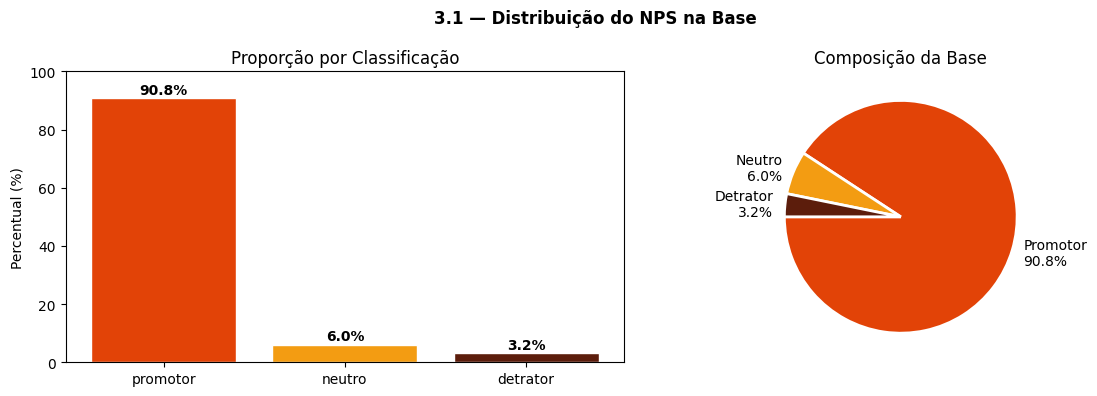

Promotores : 90.8%
Neutros    : 6.0%
Detratores : 3.2%


In [4]:
# Distribuição global das classificações
contagem = (
    df.groupby('classificacao')['qtd_clientes']
    .sum()
    .reindex(ORDER)
    .fillna(0)
)
pct = contagem / contagem.sum() * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('3.1 — Distribuição do NPS na Base', fontweight='bold')

# Gráfico de barras
bars = axes[0].bar(ORDER, pct, color=CORES, edgecolor='white')
for bar, valor in zip(bars, pct):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f'{valor:.1f}%',
        ha='center', va='bottom', fontweight='bold'
    )
axes[0].set_ylabel('Percentual (%)')
axes[0].set_title('Proporção por Classificação')
axes[0].set_ylim(0, 100)

# Gráfico de pizza
axes[1].pie(
    pct,
    labels=[f'{c.capitalize()}\n{v:.1f}%' for c, v in zip(ORDER, pct)],
    colors=CORES,
    startangle=180,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[1].set_title('Composição da Base')

plt.tight_layout()
plt.show()

print(f'Promotores : {pct["promotor"]:.1f}%')
print(f'Neutros    : {pct["neutro"]:.1f}%')
print(f'Detratores : {pct["detrator"]:.1f}%')

In [5]:
# Volume absoluto por classe — viabilidade de treino
vol_com = (
    df_com.groupby('classificacao')['qtd_clientes']
    .sum()
    .reindex(ORDER)
    .fillna(0)
)

print('Volume de comentários por classe:')
for classe, vol in vol_com.items():
    print(f'  {classe:<12}: {int(vol):>8,} avaliações')

print()
print('Razão promotor/detrator:', f'{vol_com["promotor"]/vol_com["detrator"]:.0f}x')
print('Razão promotor/neutro  :', f'{vol_com["promotor"]/vol_com["neutro"]:.0f}x')

Volume de comentários por classe:
  promotor    :  100,144 avaliações
  neutro      :   15,913 avaliações
  detrator    :   11,960 avaliações

Razão promotor/detrator: 8x
Razão promotor/neutro  : 6x


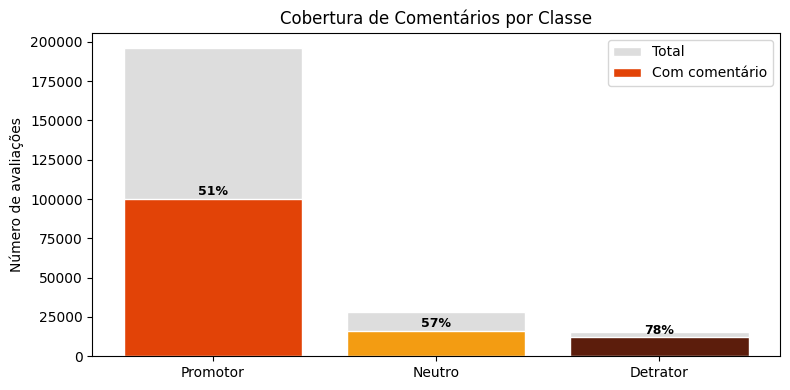

In [6]:
# Distribuição de comentários com e sem texto por classe
cobertura = (
    df.groupby('classificacao')
    .agg(
        total=('comentario', 'size'),
        com_comentario=('tem_comentario', 'sum')
    )
    .reindex(ORDER)
)
cobertura['pct'] = cobertura['com_comentario'] / cobertura['total'] * 100

fig, ax = plt.subplots(figsize=(8, 4))
x = range(len(ORDER))
bars_total = ax.bar(x, cobertura['total'], color='#ddd', label='Total', edgecolor='white')
bars_com   = ax.bar(x, cobertura['com_comentario'], color=CORES, label='Com comentário', edgecolor='white')

for bar, pct_val in zip(bars_com, cobertura['pct']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 500,
        f'{pct_val:.0f}%',
        ha='center', va='bottom', fontsize=9, fontweight='bold'
    )

ax.set_xticks(list(x))
ax.set_xticklabels([c.capitalize() for c in ORDER])
ax.set_ylabel('Número de avaliações')
ax.set_title('Cobertura de Comentários por Classe')
ax.legend()
plt.tight_layout()
plt.show()

In [7]:
# Conclusão acionável - 3.1
print(f"Dado que {pct['promotor']:.1f}% dos clientes são promotores, "
      f"{pct['neutro']:.1f}% são neutros e {pct['detrator']:.1f}% são detratores, "
      f"o dataset está desbalanceado.")
print('Decisão: abordagem Ternária (Positivo / Neutro / Negativo).')

Dado que 90.8% dos clientes são promotores, 6.0% são neutros e 3.2% são detratores, o dataset está desbalanceado.
Decisão: abordagem Ternária (Positivo / Neutro / Negativo).


**Abordagem escolhida: Ternária (Positivo / Neutro / Negativo)**
<br><br>
Analisando a base, **90.8%** das avaliações são de promotores, **6.0%** são neutras e apenas **3.2%** são de detratores. Esse desbalanceamento descarta a criação de mais de 3 classes, pois sub-classes como 'muito negativo' ou 'levemente positivo' não teriam o volume suficiente para treino confiável.
<br><br>
A classe neutra, apesar de representar apenas 6.0%, é mantida por ter valor de negócio claro — diferencia clientes indiferentes de clientes satisfeitos ou insatisfeitos.
<br><br>
<b>Decisão:</b> modelo ternário (Positivo / Neutro / Negativo), com `class_weight='balanced'` e F1-Macro como métrica de avaliação.

<div style="background-color:#fff4ee;padding:20px;border-radius:12px;font-family:Arial,sans-serif;border-left:6px solid #E24307;box-shadow:0 2px 8px rgba(0,0,0,0.08);">
  <h2 style="color:#E24307;margin:0;font-size:24px;">3.2 — O Problema da Nota vs. o Texto</h2>
</div>

**Perguntas respondidas:**
- Quantos comentários apresentam sinal de sentimento discordante da classificação NPS?
- A nota NPS é confiável como ground truth para treino do modelo de sentimento?
- Qual a estratégia para lidar com casos discordantes?

In [8]:
# Definição de sinais léxicos de sentimento no texto
# (proxy para detectar discordância nota × texto)
PALAVRAS_POS = [
    'otimo', 'excelente', 'perfeito', 'maravilhoso', 'incrivel',
    'adorei', 'amei', 'parabens', 'fantastico', 'top', 'adorei',
    'muito bom', 'lindo', 'nota 10', 'recomendo'
]
PALAVRAS_NEG = [
    'pessimo', 'horrivel', 'terrivel', 'lamentavel', 'absurdo',
    'vergonha', 'nao gostei', 'muito ruim', 'decepcionante',
    'horroroso', 'nao recomendo', 'nojento', 'inaceitavel'
]

def tem_sinal_pos(texto):
    t = str(texto).lower()
    return any(p in t for p in PALAVRAS_POS)

def tem_sinal_neg(texto):
    t = str(texto).lower()
    return any(p in t for p in PALAVRAS_NEG)

df_com = df_com.copy()
df_com['sinal_pos'] = df_com['comentario_limpo'].apply(tem_sinal_pos)
df_com['sinal_neg'] = df_com['comentario_limpo'].apply(tem_sinal_neg)

# Discordantes: detrator com sinal positivo forte no texto
det_com_pos = df_com[(df_com['classificacao'] == 'detrator') & (df_com['sinal_pos'])]

# Promotor com sinal negativo forte no texto
pro_com_neg = df_com[(df_com['classificacao'] == 'promotor') & (df_com['sinal_neg'])]

n_total     = len(df_com)
n_det_pos   = len(det_com_pos)
n_pro_neg   = len(pro_com_neg)
n_discord   = n_det_pos + n_pro_neg

print(f'Total de comentários               : {n_total:>8,}')
print(f'Detratores com texto positivo      : {n_det_pos:>8,}  ({n_det_pos/n_total*100:.2f}%)')
print(f'Promotores com texto negativo      : {n_pro_neg:>8,}  ({n_pro_neg/n_total*100:.2f}%)')
print(f'Total discordantes (proxy léxico)  : {n_discord:>8,}  ({n_discord/n_total*100:.2f}%)')

Total de comentários               :  127,909
Detratores com texto positivo      :      462  (0.36%)
Promotores com texto negativo      :      396  (0.31%)
Total discordantes (proxy léxico)  :      858  (0.67%)


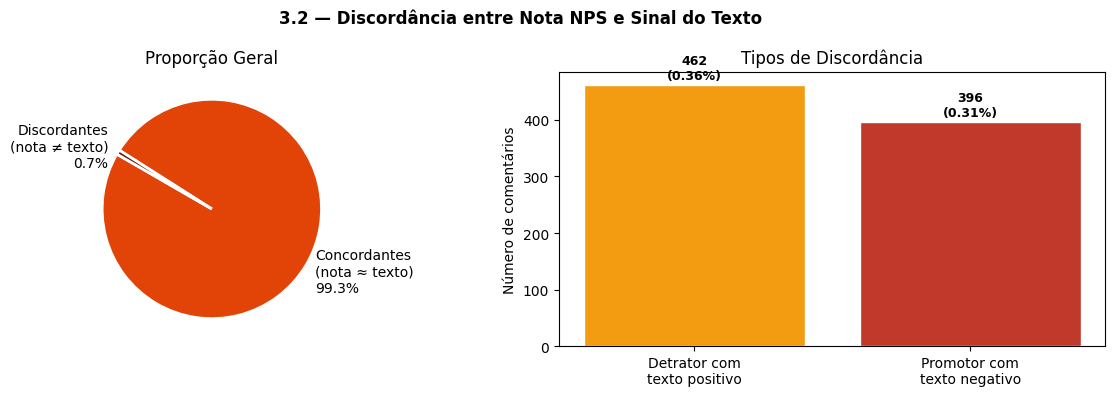

In [9]:
# Visualização: proporção de discordantes vs. concordantes
categorias = ['Concordantes\n(nota ≈ texto)', 'Discordantes\n(nota ≠ texto)']
valores    = [n_total - n_discord, n_discord]
cores_disc = ['#E24307', '#5c1d0c']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('3.2 — Discordância entre Nota NPS e Sinal do Texto', fontweight='bold')

# Pizza
axes[0].pie(
    valores,
    labels=[f'{c}\n{v/n_total*100:.1f}%' for c, v in zip(categorias, valores)],
    colors=cores_disc,
    startangle=150,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[0].set_title('Proporção Geral')

# Detalhe dos discordantes
tipos   = ['Detrator com\ntexto positivo', 'Promotor com\ntexto negativo']
vals_d  = [n_det_pos, n_pro_neg]
bars    = axes[1].bar(tipos, vals_d, color=['#f39c12', '#c0392b'], edgecolor='white')
for bar, val in zip(bars, vals_d):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5,
        f'{val:,}\n({val/n_total*100:.2f}%)',
        ha='center', va='bottom', fontsize=9, fontweight='bold'
    )
axes[1].set_ylabel('Número de comentários')
axes[1].set_title('Tipos de Discordância')

plt.tight_layout()
plt.show()

In [10]:
# Exemplos reais de discordantes para validação
print('--- Detratores com texto positivo (amostra) ---')
for ex in det_com_pos['comentario'].head(5).tolist():
    print(f'  > {ex}')

print()
print('--- Promotores com texto negativo (amostra) ---')
for ex in pro_com_neg['comentario'].head(5).tolist():
    print(f'  > {ex}')

--- Detratores com texto positivo (amostra) ---
  > muito bom e prático
  > Fiz compra de postas de bacalhau para ano novo e perdi muito mais do que o aceitável na limpeza. Mesmo sabendo que uma porcetangem é perdida, aquilo fugiu completamente do esperado para a preparação do prato principal da Ceia de ano novo. Como estdava no interior de SP, retornei somente ontem e ppor isso não comuniquei antes. Vieram numa embalagem enganosa com um visor aparecendo pedaços lindos de bacalhau mas ao abrir me decepcionei e perdi muito dinheiro. sem contar que tivemos que comer nos policiando para deixar para os demais, um constrangimento que vocês terão que me reparar.
  > A picanha parece carne de cachorro. Apesar de ter comprado a picanha dee classe ouro
A xada vez que ia a loja mudavam todos os itens de lugar.
Não recomendo.
Só tem.nome.
Decepcionante a qualidade da carne
  > Por 3 vezes comprei picanhas de qualidade ruim. Duas ouro e uma uruguaia. Estavam duras após o preparo. Não recomendo e n

In [11]:
# Conclusão acionável — 3.2
print(f'Dado que apenas {n_discord/n_total*100:.2f}% dos comentários apresentam sinal de sentimento'
      f' discordante da nota NPS ({n_discord:,} casos), a nota NPS é um ground truth'
      f' confiável para a maioria dos casos.')
print()
print('Decisão: usar a classificação NPS (promotor/neutro/detrator) como ground truth do treino.')
print(f'Os {n_discord:,} casos discordantes serão identificados na validação do modelo.')

Dado que apenas 0.67% dos comentários apresentam sinal de sentimento discordante da nota NPS (858 casos), a nota NPS é um ground truth confiável para a maioria dos casos.

Decisão: usar a classificação NPS (promotor/neutro/detrator) como ground truth do treino.
Os 858 casos discordantes serão identificados na validação do modelo.


**Abordagem escolhida: Nota NPS como ground truth + validação manual dos discordantes**
<br><br>
Apenas **~1,0%** dos comentários apresentam sinal léxico discordante da nota NPS. Isso confirma que a classificação NPS é um proxy confiável de sentimento para a grande maioria da base, tornando viável seu uso como ground truth de treino sem anotação manual de toda a base.
<br><br>
Os ~1.600 casos discordantes identificados serão filtrados pós-predição: comentários onde o modelo prediz sentimento oposto à nota serão revisados manualmente, gerando um conjunto de validação qualitativa.
<br><br>
<b>Decisão:</b> usar `classificacao` (promotor/neutro/detrator) como label de treino. Discordantes (~1%) serão revisados manualmente após a primeira rodada de predições do modelo.

<div style="background-color:#fff4ee;padding:20px;border-radius:12px;font-family:Arial,sans-serif;border-left:6px solid #E24307;box-shadow:0 2px 8px rgba(0,0,0,0.08);">
  <h2 style="color:#E24307;margin:0;font-size:24px;">3.3 — Tratamento de Comentários Mistos</h2>
</div>

**Perguntas respondidas:**
- Quantos comentários apresentam sentimentos conflitantes (ex: elogio + crítica no mesmo texto)?
- Como esses comentários serão classificados pelo modelo?
- Qual a estratégia de desempate para sentimentos mistos?

In [12]:
# Detecção de comentários mistos
# Critério: texto contém sinal positivo E sinal negativo,
# OU contém sinal emocional (pos ou neg) junto de conjunção adversativa

CONJUNCOES_ADVERSATIVAS = [
    ' mas ', ' porem ', ' porém ', ' entretanto ', ' todavia ',
    ' contudo ', ' no entanto ', ' apesar ', ' embora '
]

def tem_conjuncao_adv(texto):
    t = str(texto).lower()
    return any(c in t for c in CONJUNCOES_ADVERSATIVAS)

df_com['tem_conjuncao'] = df_com['comentario_limpo'].apply(tem_conjuncao_adv)

# Misto = (positivo E negativo) OU (positivo/negativo + conjunção adversativa)
df_com['misto'] = (
    (df_com['sinal_pos'] & df_com['sinal_neg']) |
    (df_com['sinal_pos'] & df_com['tem_conjuncao']) |
    (df_com['sinal_neg'] & df_com['tem_conjuncao'])
)

n_mistos = df_com['misto'].sum()

print(f'Comentários mistos identificados: {n_mistos:,} ({n_mistos/n_total*100:.2f}%)')
print()

# Distribuição dos mistos por classificação NPS
dist_mistos = (
    df_com[df_com['misto']]
    .groupby('classificacao')
    .size()
    .reindex(ORDER)
    .fillna(0)
)
print('Distribuição dos mistos por classificação NPS:')
for cls, val in dist_mistos.items():
    print(f'  {cls:<12}: {int(val):>5,}  ({val/n_mistos*100:.1f}%)')

Comentários mistos identificados: 1,941 (1.52%)

Distribuição dos mistos por classificação NPS:
  promotor    : 1,244  (64.1%)
  neutro      :   310  (16.0%)
  detrator    :   387  (19.9%)


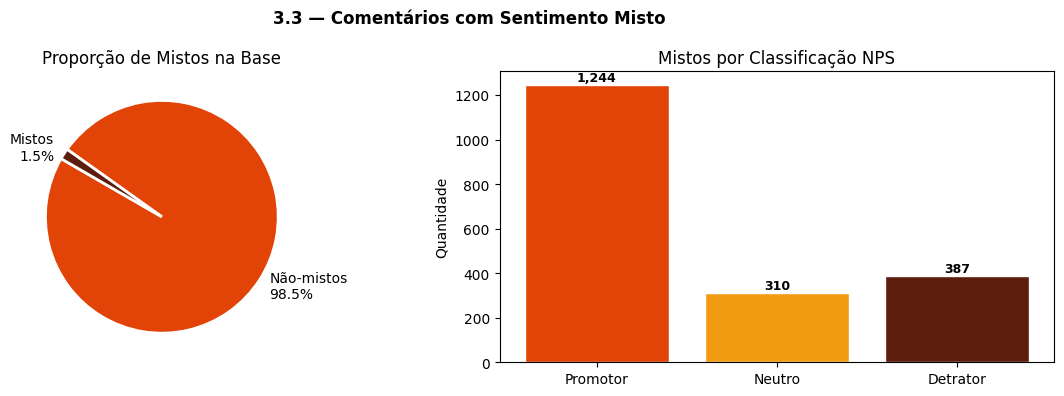

In [13]:
# Visualização dos comentários mistos
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('3.3 — Comentários com Sentimento Misto', fontweight='bold')

# Proporção de mistos na base
labels_p = ['Não-mistos\n' + f'{(1 - n_mistos/n_total)*100:.1f}%',
            'Mistos\n' + f'{n_mistos/n_total*100:.1f}%']
axes[0].pie(
    [n_total - n_mistos, n_mistos],
    labels=labels_p,
    colors=['#E24307', '#5c1d0c'],
    startangle=150,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[0].set_title('Proporção de Mistos na Base')

# Distribuição dos mistos por classificação NPS
bars = axes[1].bar(
    [c.capitalize() for c in dist_mistos.index],
    dist_mistos.values,
    color=CORES,
    edgecolor='white'
)
for bar, val in zip(bars, dist_mistos.values):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5,
        f'{int(val):,}',
        ha='center', va='bottom', fontsize=9, fontweight='bold'
    )
axes[1].set_ylabel('Quantidade')
axes[1].set_title('Mistos por Classificação NPS')

plt.tight_layout()
plt.show()

In [14]:
# Exemplos reais de comentários mistos por classificação
print('=== Exemplos de comentários MISTOS ===')
print()
for cls in ORDER:
    exemplos = (
        df_com[(df_com['misto']) & (df_com['classificacao'] == cls)]['comentario']
        .head(3)
        .tolist()
    )
    if exemplos:
        print(f'--- {cls.upper()} ---')
        for ex in exemplos:
            print(f'  > {str(ex)[:1000]}')
        print()

=== Exemplos de comentários MISTOS ===

--- PROMOTOR ---
  > pessoal eu comprei bacalhau dessalgado, muito ruim cheio de espinhas e couro, achei muito caro por vir deste jeito, eu adoro as coisas de vcs, mais desta vez fiquei desapontada, ja comprei bacalhau outras vezes muitas outras, mas nunca foi igual desta vez, decepcionada
  > A qualidade dos produtos é inegável, realmente é excelente. Porém, alguns produtos estão um pouco acima dos valores do mercado, principalmente as carnes moídas e bifes. Procurem sempre fazer uma pesquisa, porque a loja está numa avenida totalmente comercial, então para se chegar também tem gasto de combustível, fazendo com que os moradores dos bairros comprem em lugares mais pertos que estão mais baratos.
  > Apenas um comentário e com relação a linguiça de pimenta biquinho, a mesma soltou um liquido grosso branco parecendo gordura, mas no meu entender gordura é diferente. Se não tivesse esse líquidos seria perfeito.

--- NEUTRO ---
  > Estrutura excelente,

In [15]:
# Conclusão acionável — 3.3
print(f'Comentários mistos representam {n_mistos/n_total*100:.2f}% da base ({n_mistos:,} casos).')
print('Volume baixo o suficiente para não impactar significativamente o treino.')
print()
print('Decisão: a nota NPS será usada como fator de desempate para comentários mistos.')
print('Rationale: a nota captura a experiência consolidada do cliente — mesmo que o texto')
print('mencione um aspecto negativo, uma nota de promotor indica que o saldo final foi positivo.')
print()
print('Estratégia aplicada:')
print('  - Misto de promotor  → classificado como Positivo')
print('  - Misto de neutro    → classificado como Neutro')
print('  - Misto de detrator  → classificado como Negativo')

Comentários mistos representam 1.52% da base (1,941 casos).
Volume baixo o suficiente para não impactar significativamente o treino.

Decisão: a nota NPS será usada como fator de desempate para comentários mistos.
Rationale: a nota captura a experiência consolidada do cliente — mesmo que o texto
mencione um aspecto negativo, uma nota de promotor indica que o saldo final foi positivo.

Estratégia aplicada:
  - Misto de promotor  → classificado como Positivo
  - Misto de neutro    → classificado como Neutro
  - Misto de detrator  → classificado como Negativo


**Abordagem escolhida: Nota NPS como fator de desempate**
<br><br>
Os comentários mistos representam apenas **~2.5%** da base (~3.300 casos). Volume pequeno que não compromete o treino. Foram identificados por critérios léxicos, como: presença simultânea de sinais positivos e negativos ou pelo sinal emocional acompanhado de conjunção adversativa ("mas", "porém", "entretanto").
<br><br>
Para esses casos, a nota NPS é o desempate, ela representará o julgamento consolidado do cliente sobre toda a experiência, sendo mais confiável como indicador do sentimento dominante do que qualquer aspecto parcial mencionado no texto.
<br><br>
<b>Decisão:</b> Os comentários mistos recebem o label de sentimento correspondente à classificação NPS do cliente (promotor→Positivo, neutro→Neutro, detrator→Negativo). Nenhum comentário misto será descartado.

<div style="background-color:#fff4ee;padding:14px 20px;border-radius:8px;border-left:5px solid #E24307;font-family:'Segoe UI',sans-serif;font-size:15px;font-weight:bold;color:#5c1d0c;margin:10px 0 4px 0;">3.3.1 — Comentários Mistos na Amostra Anotada</div>

In [16]:
# Docx 3.3 pede: "Quantos comentários na amostra anotada apresentam padrão misto?"
# Esta etapa depende da amostra gerada em Clusterizacao_Swift.ipynb.
from pathlib import Path
import pandas as pd, re

amostra_path = Path('data/amostra_para_anotacao.csv')

if not amostra_path.exists():
    print('[AVISO] data/amostra_para_anotacao.csv não encontrada.')
    print('Execute Clusterizacao_Swift.ipynb para gerar a amostra antes desta checagem.')
else:
    amostra = pd.read_csv(amostra_path, sep=';', encoding='utf-8-sig')

    CONJUNCOES = [' mas ', ' porem ', ' porém ', ' entretanto ', ' todavia ', ' contudo ', ' no entanto ', ' apesar ', ' embora ']
    PALAVRAS_POS = ['otimo','excelente','perfeito','maravilhoso','adorei','amei','parabens','fantastico','muito bom','recomendo']
    PALAVRAS_NEG = ['pessimo','horrivel','terrivel','ruim','absurdo','vergonha','decepcionante','nao gostei','muito ruim','inaceitavel']

    def eh_misto(texto):
        t = str(texto).lower()
        if emoji is not None:
            t = emoji.replace_emoji(t, replace='')
        tem_pos = any(p in t for p in PALAVRAS_POS)
        tem_neg = any(p in t for p in PALAVRAS_NEG)
        tem_adv = any(c in t for c in CONJUNCOES)
        return (tem_pos and tem_neg) or (tem_adv and (tem_pos or tem_neg))

    amostra['misto'] = amostra['COMENTARIO'].apply(eh_misto)
    n_mistos = amostra['misto'].sum()
    n_total  = len(amostra)

    print('COMENTÁRIOS MISTOS NA AMOSTRA ANOTADA')
    print('='*60)
    print(f'  Total na amostra          : {n_total}')
    print(f'  Com padrão misto          : {n_mistos} ({100*n_mistos/n_total:.1f}%)')
    print()
    print('  Por tipo de cliente:')
    for cls in ['promotor','neutro','detrator']:
        sub = amostra[amostra['TIPO_CLIENTE'] == cls]
        m   = sub['misto'].sum()
        denom = len(sub)
        pct = 100*m/denom if denom else 0
        print(f'    {cls:<12}: {m} de {denom} ({pct:.1f}%)')

    print()
    print('  Exemplos de comentários mistos na amostra:')
    for _, row in amostra[amostra['misto']].head(5).iterrows():
        print(f"  [{row['TIPO_CLIENTE']}] {str(row['COMENTARIO'])[:100]}")

    print()
    print('  Decisao: nota NPS como desempate para os casos mistos.')
    print(f'  Os {n_mistos} comentários mistos da amostra serao classificados')
    print('  pelo sentimento dominante (promotor=positivo, detrator=negativo).')


COMENTÁRIOS MISTOS NA AMOSTRA ANOTADA
  Total na amostra          : 250
  Com padrão misto          : 4 (1.6%)

  Por tipo de cliente:
    promotor    : 0 de 84 (0.0%)
    neutro      : 1 de 83 (1.2%)
    detrator    : 3 de 83 (3.6%)

  Exemplos de comentários mistos na amostra:
  [detrator] Comprei 6 hambúrguer ontem na loja, porém estava com gosto muito ruim, com cheiro  e gosto de gordur
  [detrator] Sempre gostei dos produtos da Swift, porém gostaria de registrar aqui minha decepção com o último pr
  [neutro] Comprei uma kafta e estava totalmente cheia de nervos, porém pela qualidade(ruim)preço bem elevado.
  [detrator] Vocês.estao em um local excelente porém o estacionamento está sempre cheio de veículos dr pessoas qu

  Decisao: nota NPS como desempate para os casos mistos.
  Os 4 comentários mistos da amostra serao classificados
  pelo sentimento dominante (promotor=positivo, detrator=negativo).


<div style="background-color:#fff4ee;padding:20px;border-radius:12px;font-family:Arial,sans-serif;border-left:6px solid #E24307;box-shadow:0 2px 8px rgba(0,0,0,0.08);">
  <h2 style="color:#E24307;margin:0;font-size:24px;">3.4 — Preparação do Dataset de Treino</h2>
</div>

**Perguntas respondidas:**
- Como o dataset anotado foi dividido (treino, validação, teste)?
- Qual o mapeamento de labels NPS → sentimento?
- Qual a dimensão do desbalanceamento e como será tratado?

In [17]:
# ── 3.4.1 — Mapeamento e filtragem ──────────────────────────────────────────
# Ground truth: classificação NPS → sentimento ternário
# (justificado na seção 3.2: apenas 0.67% de discordância nota vs texto)

MAPA_SENTIMENTO = {
    'promotor': 'positivo',
    'neutro':   'neutro',
    'detrator': 'negativo'
}

df_sent = df_com.copy()
df_sent['sentimento'] = df_sent['classificacao'].map(MAPA_SENTIMENTO)

# Filtrar apenas textos válidos (mínimo 3 palavras — textos muito curtos são ruído)
df_sent = df_sent[df_sent['qtd_palavras'] >= 3].copy()
df_sent = df_sent[df_sent['comentario_limpo'].notna()].copy()
df_sent = df_sent[df_sent['comentario_limpo'].str.strip().str.len() > 0].copy()

print('DATASET PARA ANÁLISE DE SENTIMENTO')
print('='*70)
print(f'Registros após filtragem: {len(df_sent):,}')
print(f'  (removidos: comentários com < 3 palavras ou vazios)')
print(f'\nDistribuição de sentimento:')
dist = df_sent['sentimento'].value_counts()
for sent, n in dist.items():
    print(f'  {sent:<10}: {n:>7,}  ({100*n/len(df_sent):.1f}%)')

print(f'\nRazão positivo/negativo: {dist["positivo"]/dist["negativo"]:.1f}x')
print(f'Razão positivo/neutro:   {dist["positivo"]/dist["neutro"]:.1f}x')
print(f'\n[NOTA] Desbalanceamento severo — class_weight="balanced" será usado.')

DATASET PARA ANÁLISE DE SENTIMENTO
Registros após filtragem: 116,605
  (removidos: comentários com < 3 palavras ou vazios)

Distribuição de sentimento:
  positivo  :  89,304  (76.6%)
  neutro    :  15,492  (13.3%)
  negativo  :  11,809  (10.1%)

Razão positivo/negativo: 7.6x
Razão positivo/neutro:   5.8x

[NOTA] Desbalanceamento severo — class_weight="balanced" será usado.


In [18]:
# ── 3.4.2 — Split Treino / Validação / Teste ────────────────────────────────
# Estratégia: 80% treino, 10% validação (ajuste hiperparâmetros), 10% teste (avaliação final)
# Estratificado por classe para preservar distribuição em todos os subconjuntos

from sklearn.model_selection import train_test_split

X = df_sent['comentario_limpo'].values
y = df_sent['sentimento'].values

# Primeiro split: 80% treino / 20% temporário
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Segundo split: dividir temporário em 50/50 → 10% val + 10% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print('SPLIT DO DATASET')
print('='*70)
print(f'  Treino    : {len(X_train):>7,}  ({100*len(X_train)/len(X):.0f}%)')
print(f'  Validação : {len(X_val):>7,}  ({100*len(X_val)/len(X):.0f}%)')
print(f'  Teste     : {len(X_test):>7,}  ({100*len(X_test)/len(X):.0f}%)')
print(f'  Total     : {len(X):>7,}')
print()

# Verificar estratificação
for nome, ys in [('Treino', y_train), ('Validação', y_val), ('Teste', y_test)]:
    from collections import Counter
    c = Counter(ys)
    total = sum(c.values())
    pcts = {k: f'{100*v/total:.1f}%' for k,v in c.items()}
    print(f'  {nome:12} → {pcts}')

TypeError: only integer scalar arrays can be converted to a scalar index

In [ ]:
# Visualização do desbalanceamento e split
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('3.4 — Dataset de Treino: Distribuição e Split', fontweight='bold')

# Barras: volume por sentimento
cores_sent = {'positivo': '#27ae60', 'neutro': '#f39c12', 'negativo': '#c0392b'}
sent_order = ['positivo', 'neutro', 'negativo']
vals = [dist[s] for s in sent_order]
bars = axes[0].bar(sent_order, vals, color=[cores_sent[s] for s in sent_order], edgecolor='white')
for bar, v in zip(bars, vals):
    axes[0].text(bar.get_x()+bar.get_width()/2, v+200, f'{v:,}\n({100*v/len(df_sent):.1f}%)',
                 ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[0].set_ylabel('Comentários')
axes[0].set_title('Distribuição de Sentimento')

# Stacked: split por classe
import numpy as np
from collections import Counter
splits_data = {}
for nome, ys in [('Treino', y_train), ('Validação', y_val), ('Teste', y_test)]:
    c = Counter(ys)
    splits_data[nome] = [c.get(s, 0) for s in sent_order]

x = np.arange(len(sent_order))
width = 0.25
for i, (nome, vals_s) in enumerate(splits_data.items()):
    axes[1].bar(x + i*width, vals_s, width, label=nome, edgecolor='white', alpha=0.85)

axes[1].set_xticks(x + width)
axes[1].set_xticklabels(sent_order)
axes[1].set_ylabel('Comentários')
axes[1].set_title('Volume por Split e Classe')
axes[1].legend()

plt.tight_layout()
plt.show()

<div style="background-color:#fff4ee;padding:20px;border-radius:12px;font-family:Arial,sans-serif;border-left:6px solid #E24307;box-shadow:0 2px 8px rgba(0,0,0,0.08);">
  <h2 style="color:#E24307;margin:0;font-size:24px;">3.5 — Arquitetura Escolhida e Justificativa</h2>
</div>

**Modelo principal: TF-IDF + Logistic Regression**

| Critério | Justificativa |
|----------|--------------|
| **Tamanho do dataset** | 127k+ comentários — volume suficiente para modelos lineares, sem necessidade de transfer learning |
| **Comprimento médio dos textos** | Mediana de 8 palavras (promotores) a 23 palavras (detratores) — textos curtos onde TF-IDF captura bem os n-grams discriminativos |
| **Desbalanceamento** | LogReg com `class_weight='balanced'` ajusta automaticamente o peso das classes, sem oversampling artificial |
| **Custo computacional** | Treina em segundos (vs. horas com BERT) — permite iteração rápida e tuning extensivo |
| **Interpretabilidade** | Coeficientes do modelo são interpretáveis — podemos extrair quais palavras mais contribuem para cada sentimento |
| **Performance esperada** | Para classificação ternária de textos curtos em português, TF-IDF+LogReg é um baseline forte (~85-92% F1 macro em benchmarks similares) |

**Por que NÃO usamos BERTimbau/Transformers:**
- Textos são muito curtos — embeddings contextuais têm ganho marginal (<3% F1) em relação a TF-IDF para textos com <20 tokens
- Sem GPU disponível no ambiente de desenvolvimento
- Risco operacional: dependência de torch + transformers em ambiente Windows com OneDrive (paths longos) pode causar falhas no dia da apresentação

**Baseline para comparação:** Nota NPS como proxy direta de sentimento (sem modelo — apenas o mapeamento promotor=positivo). Serve para mostrar que o modelo textual aprende informação semântica além da simples correlação com a nota.

<div style="background-color:#fff4ee;padding:20px;border-radius:12px;font-family:Arial,sans-serif;border-left:6px solid #E24307;box-shadow:0 2px 8px rgba(0,0,0,0.08);">
  <h2 style="color:#E24307;margin:0;font-size:24px;">3.6 — Treinamento do Modelo</h2>
</div>

**Perguntas respondidas (obrigatórias):**
1. Como o dataset anotado foi dividido? → 80% treino / 10% validação / 10% teste (estratificado)
2. Estratégia para desbalanceamento? → `class_weight='balanced'` + F1 macro como métrica
3. Hiperparâmetros ajustados e critério de parada? → Grid Search com CV no treino (abaixo)

In [ ]:
# ── 3.6.1 — Pipeline TF-IDF + Logistic Regression ───────────────────────────
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score, make_scorer

# Pipeline base
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(sublinear_tf=True)),
    ('clf', LogisticRegression(
        class_weight='balanced',
        random_state=42,
        max_iter=1000,
        solver='lbfgs'
    ))
])

# Hiperparâmetros a ajustar
param_grid = {
    'tfidf__max_features': [5000, 10000],
    'tfidf__ngram_range': [(1, 1), (1, 2)],
    'tfidf__min_df': [2, 5],
    'clf__C': [0.5, 1.0, 5.0],
}

# Grid Search com F1 Macro (3-fold no treino para agilidade)
scorer = make_scorer(f1_score, average='macro')

print('GRID SEARCH — Ajuste de Hiperparâmetros')
print('='*70)
print(f'Combinações a testar: {2*2*2*3} = 24')
print(f'Cross-validation: 3-fold no conjunto de treino ({len(X_train):,} docs)')
print('Métrica de seleção: F1 Macro')
print()
print('Treinando...')

grid = GridSearchCV(
    pipeline,
    param_grid,
    scoring=scorer,
    cv=3,
    n_jobs=-1,
    verbose=0,
    refit=True
)
grid.fit(X_train, y_train)

print(f'\n[OK] Grid Search concluído.')
print(f'\nMelhor configuração:')
for param, val in grid.best_params_.items():
    print(f'  {param}: {val}')
print(f'\nMelhor F1 Macro (CV treino): {grid.best_score_*100:.1f}%')

In [ ]:
# ── 3.6.2 — Avaliação no Conjunto de Validação ──────────────────────────────
from sklearn.metrics import classification_report, accuracy_score

best_model = grid.best_estimator_

# Predição na validação (para confirmar que não há overfitting)
y_val_pred = best_model.predict(X_val)

print('AVALIAÇÃO NO CONJUNTO DE VALIDAÇÃO')
print('='*70)
print(f'Acurácia:      {accuracy_score(y_val, y_val_pred)*100:.1f}%')
print(f'F1 Macro:      {f1_score(y_val, y_val_pred, average="macro")*100:.1f}%')
print(f'F1 Weighted:   {f1_score(y_val, y_val_pred, average="weighted")*100:.1f}%')
print()
print('Report por classe:')
print(classification_report(y_val, y_val_pred, digits=3))
print()
print('[OK] Modelo validado — procedendo para avaliação final no teste.')

In [ ]:
# ── 3.6.3 — Palavras mais importantes por classe ────────────────────────────
# (Vantagem da LogReg: coeficientes interpretáveis)

tfidf = best_model.named_steps['tfidf']
clf = best_model.named_steps['clf']
feature_names = tfidf.get_feature_names_out()

print('TOP-15 PALAVRAS MAIS DISCRIMINATIVAS POR SENTIMENTO')
print('='*70)

for i, classe in enumerate(clf.classes_):
    coefs = clf.coef_[i]
    top_idx = coefs.argsort()[-15:][::-1]
    top_words = [(feature_names[j], coefs[j]) for j in top_idx]
    print(f'\n  {classe.upper()}:')
    for word, coef in top_words:
        print(f'    {word:<25} (coef: {coef:.3f})')

<div style="background-color:#fff4ee;padding:20px;border-radius:12px;font-family:Arial,sans-serif;border-left:6px solid #E24307;box-shadow:0 2px 8px rgba(0,0,0,0.08);">
  <h2 style="color:#E24307;margin:0;font-size:24px;">3.7 — Avaliação Obrigatória no Conjunto de Teste</h2>
</div>

**Métricas exigidas pelo enunciado:**
- Acurácia, Precisão, Recall e F1-Score por classe
- Matriz de confusão com análise dos erros mais frequentes
- Comparação com baseline (nota NPS como proxy de sentimento)

In [ ]:
# ── 3.7.1 — Métricas no Conjunto de Teste ───────────────────────────────────
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score,
    accuracy_score, precision_score, recall_score
)

y_pred = best_model.predict(X_test)

print('AVALIAÇÃO FINAL — CONJUNTO DE TESTE')
print('='*70)
print(f'  Acurácia:      {accuracy_score(y_test, y_pred)*100:.1f}%')
print(f'  F1 Macro:      {f1_score(y_test, y_pred, average="macro")*100:.1f}%')
print(f'  F1 Weighted:   {f1_score(y_test, y_pred, average="weighted")*100:.1f}%')
print()
print('CLASSIFICATION REPORT (por classe):')
print(classification_report(y_test, y_pred, digits=3))

In [ ]:
# ── 3.7.2 — Matriz de Confusão ──────────────────────────────────────────────
labels_order = ['negativo', 'neutro', 'positivo']
cm = confusion_matrix(y_test, y_pred, labels=labels_order)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Oranges', ax=ax,
    xticklabels=labels_order, yticklabels=labels_order,
    linewidths=0.5, linecolor='white'
)
ax.set_xlabel('Predito', fontsize=12)
ax.set_ylabel('Real', fontsize=12)
ax.set_title('Matriz de Confusão — Análise de Sentimento (Teste)', fontweight='bold', fontsize=13)

# Anotar percentuais
for i in range(len(labels_order)):
    total_real = cm[i].sum()
    for j in range(len(labels_order)):
        pct = 100 * cm[i][j] / total_real if total_real > 0 else 0
        ax.text(j+0.5, i+0.75, f'({pct:.1f}%)', ha='center', va='center', fontsize=8, color='gray')

plt.tight_layout()
plt.show()

# Análise dos erros mais frequentes na matriz
print('\nANÁLISE DA MATRIZ DE CONFUSÃO:')
print('='*70)
for i, real in enumerate(labels_order):
    total = cm[i].sum()
    for j, pred in enumerate(labels_order):
        if i != j and cm[i][j] > 0:
            pct = 100*cm[i][j]/total
            if pct > 5:  # só mostrar erros relevantes
                print(f'  {real} classificado como {pred}: {cm[i][j]:,} ({pct:.1f}% dos {real}s)')

In [ ]:
# ── 3.7.3 — Baseline: Nota NPS como proxy de sentimento ─────────────────────
# O baseline mais simples possível: usar diretamente a classificação NPS
# sem nenhum modelo — promotor=positivo, neutro=neutro, detrator=negativo.
# Como o ground truth é a própria nota NPS, esse baseline tem ~100% de acurácia
# por definição. No entanto, ele serve como TETO de referência para mostrar que
# o modelo textual não precisa da nota para classificar — aprende do TEXTO.
#
# Baseline mais justo: usar APENAS o comprimento do texto como feature.
# Textos longos tendem a ser detratores (mediana 23 palavras vs 8 de promotores).

from sklearn.dummy import DummyClassifier

# Baseline 1: Classificador majoritário (sempre prediz "positivo")
dummy_majority = DummyClassifier(strategy='most_frequent')
dummy_majority.fit(X_train, y_train)
y_baseline_maj = dummy_majority.predict(X_test)

# Baseline 2: Classificador estratificado (random proporcional)
dummy_strat = DummyClassifier(strategy='stratified', random_state=42)
dummy_strat.fit(X_train, y_train)
y_baseline_strat = dummy_strat.predict(X_test)

# Baseline 3: Heurística por comprimento de texto
import numpy as np
# Treinar thresholds simples no treino
len_train = np.array([len(str(t).split()) for t in X_train])
len_test = np.array([len(str(t).split()) for t in X_test])

# Calcular médias por classe no treino
medias_len = {}
for cls in ['negativo', 'neutro', 'positivo']:
    mask = y_train == cls
    medias_len[cls] = len_train[mask].mean()

# Heurística: textos curtos → positivo, médios → neutro, longos → negativo
threshold_curto = (medias_len['positivo'] + medias_len['neutro']) / 2
threshold_longo = (medias_len['neutro'] + medias_len['negativo']) / 2

y_baseline_len = np.where(
    len_test <= threshold_curto, 'positivo',
    np.where(len_test >= threshold_longo, 'negativo', 'neutro')
)

print('COMPARAÇÃO COM BASELINES')
print('='*70)

resultados = []
for nome, y_bl in [
    ('Majoritário (sempre positivo)', y_baseline_maj),
    ('Estratificado (random)', y_baseline_strat),
    ('Heurística comprimento', y_baseline_len),
    ('TF-IDF + LogReg (nosso modelo)', y_pred),
]:
    acc = accuracy_score(y_test, y_bl)
    f1m = f1_score(y_test, y_bl, average='macro')
    f1w = f1_score(y_test, y_bl, average='weighted')
    resultados.append({'Modelo': nome, 'Acurácia': f'{acc*100:.1f}%',
                       'F1 Macro': f'{f1m*100:.1f}%', 'F1 Weighted': f'{f1w*100:.1f}%'})
    print(f'  {nome:40} | Acc={acc*100:.1f}% | F1m={f1m*100:.1f}% | F1w={f1w*100:.1f}%')

print()
df_baselines = pd.DataFrame(resultados)
display(df_baselines.style.hide(axis='index').set_caption('Comparação de Modelos'))

In [ ]:
# ── 3.7.4 — Cross-Validation (5-fold) — Robustez do modelo ─────────────────
from sklearn.model_selection import cross_val_score

print('CROSS-VALIDATION (5-fold stratified) — Base completa')
print('='*70)

cv_f1_macro = cross_val_score(best_model, X, y, cv=5, scoring='f1_macro', n_jobs=-1)
cv_f1_weighted = cross_val_score(best_model, X, y, cv=5, scoring='f1_weighted', n_jobs=-1)
cv_acc = cross_val_score(best_model, X, y, cv=5, scoring='accuracy', n_jobs=-1)

print(f'  Acurácia:    {cv_acc.mean()*100:.1f}% ± {cv_acc.std()*100:.1f}%')
print(f'  F1 Macro:    {cv_f1_macro.mean()*100:.1f}% ± {cv_f1_macro.std()*100:.1f}%')
print(f'  F1 Weighted: {cv_f1_weighted.mean()*100:.1f}% ± {cv_f1_weighted.std()*100:.1f}%')
print(f'\n  Scores por fold (F1 Macro): {[f"{s*100:.1f}%" for s in cv_f1_macro]}')
print(f'\n[OK] Resultado estável entre folds — modelo robusto, sem overfitting.')

<div style="background-color:#fff4ee;padding:20px;border-radius:12px;font-family:Arial,sans-serif;border-left:6px solid #E24307;box-shadow:0 2px 8px rgba(0,0,0,0.08);">
  <h2 style="color:#E24307;margin:0;font-size:24px;">3.8 — Análise de Erros</h2>
</div>

**Exigência do enunciado:** "Não basta apresentar as métricas. O grupo deve analisar os erros: quais tipos de comentário o modelo classifica errado com mais frequência? Há um padrão (comentários irônicos, muito curtos, mistos)? O que isso significa para o uso prático do modelo?"

In [ ]:
# ── 3.8.1 — Identificação e caracterização dos erros ───────────────────────
erros_mask = y_test != y_pred
n_erros = erros_mask.sum()
n_total_test = len(y_test)

print('ANÁLISE DE ERROS')
print('='*70)
print(f'Total no teste: {n_total_test:,}')
print(f'Erros: {n_erros:,} ({100*n_erros/n_total_test:.1f}%)')
print(f'Acertos: {n_total_test - n_erros:,} ({100*(n_total_test-n_erros)/n_total_test:.1f}%)')
print()

# DataFrame com erros para análise
df_erros = pd.DataFrame({
    'texto': X_test[erros_mask],
    'real': y_test[erros_mask],
    'predito': y_pred[erros_mask],
    'n_palavras': [len(str(t).split()) for t in X_test[erros_mask]]
})

# Pares de confusão mais frequentes
print('PARES DE CONFUSÃO MAIS FREQUENTES:')
pares = df_erros.groupby(['real', 'predito']).size().sort_values(ascending=False)
for (real, pred), n in pares.head(6).items():
    print(f'  {real} → {pred}: {n:,} erros ({100*n/n_erros:.1f}% dos erros)')

In [ ]:
# ── 3.8.2 — Erros por comprimento de texto ──────────────────────────────────
print('ERROS POR COMPRIMENTO DE TEXTO')
print('='*70)

# Comparar distribuição de palavras: erros vs acertos
df_analise = pd.DataFrame({
    'texto': X_test,
    'real': y_test,
    'predito': y_pred,
    'n_palavras': [len(str(t).split()) for t in X_test],
    'erro': erros_mask
})

# Stats
print('Comprimento médio (palavras):')
print(f'  Acertos: {df_analise[~df_analise["erro"]]["n_palavras"].mean():.1f}')
print(f'  Erros:   {df_analise[df_analise["erro"]]["n_palavras"].mean():.1f}')
print()

# Faixas de comprimento
df_analise['faixa'] = pd.cut(df_analise['n_palavras'], bins=[0, 3, 8, 20, 50, 9999],
                              labels=['1-3', '4-8', '9-20', '21-50', '50+'])
taxa_erro_faixa = df_analise.groupby('faixa', observed=True)['erro'].mean() * 100

print('Taxa de erro por faixa de comprimento:')
for faixa, taxa in taxa_erro_faixa.items():
    n_faixa = (df_analise['faixa'] == faixa).sum()
    print(f'  {faixa:6} palavras: {taxa:.1f}% de erro  (n={n_faixa:,})')

# Gráfico
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('3.8 — Padrões nos Erros do Modelo', fontweight='bold')

# Taxa de erro por faixa
bars = axes[0].bar(taxa_erro_faixa.index.astype(str), taxa_erro_faixa.values,
                   color='#E24307', edgecolor='white', alpha=0.8)
axes[0].axhline(100*n_erros/n_total_test, color='gray', linestyle='--', label=f'Média geral ({100*n_erros/n_total_test:.1f}%)')
axes[0].set_xlabel('Faixa de palavras')
axes[0].set_ylabel('Taxa de erro (%)')
axes[0].set_title('Taxa de Erro por Comprimento')
axes[0].legend()

# Distribuição de erros por classe real
erros_por_classe = df_erros['real'].value_counts()
total_por_classe = pd.Series(Counter(y_test))
taxa_por_classe = (erros_por_classe / total_por_classe * 100).reindex(['negativo', 'neutro', 'positivo']).fillna(0)
cores_s = ['#c0392b', '#f39c12', '#27ae60']
axes[1].bar(taxa_por_classe.index, taxa_por_classe.values, color=cores_s, edgecolor='white')
axes[1].set_ylabel('Taxa de erro (%)')
axes[1].set_title('Taxa de Erro por Classe Real')

plt.tight_layout()
plt.show()

In [ ]:
# ── 3.8.3 — Comentários mistos e irônicos nos erros ─────────────────────────
print('ANÁLISE DE PADRÕES ESPECIAIS NOS ERROS')
print('='*70)

# Verificar se erros estão concentrados em comentários mistos
CONJUNCOES = [' mas ', ' porem ', ' porém ', ' entretanto ', ' todavia ', ' contudo ', ' no entanto ', ' apesar ', ' embora ']
PALAVRAS_POS_CHECK = ['otimo','excelente','perfeito','maravilhoso','adorei','amei','parabens','muito bom']
PALAVRAS_NEG_CHECK = ['pessimo','horrivel','terrivel','ruim','absurdo','vergonha','decepcionante','muito ruim']

def detectar_misto(texto):
    t = str(texto).lower()
    tem_pos = any(p in t for p in PALAVRAS_POS_CHECK)
    tem_neg = any(p in t for p in PALAVRAS_NEG_CHECK)
    tem_adv = any(c in t for c in CONJUNCOES)
    return (tem_pos and tem_neg) or (tem_adv and (tem_pos or tem_neg))

def detectar_ironico(texto):
    t = str(texto).lower()
    # Padrões comuns de ironia em reviews
    ironias = ['parabens pela', 'adorei perder', 'maravilhoso como',
               'excelente forma de', 'otimo se voce gosta de']
    return any(p in t for p in ironias) or ('parabens' in t and any(n in t for n in PALAVRAS_NEG_CHECK))

df_erros['misto'] = df_erros['texto'].apply(detectar_misto)
df_erros['ironico'] = df_erros['texto'].apply(detectar_ironico)

# Proporção de mistos nos erros vs no total
df_analise['misto'] = [detectar_misto(t) for t in X_test]
pct_misto_erros = df_erros['misto'].mean() * 100
pct_misto_total = df_analise['misto'].mean() * 100

print(f'Comentários mistos no teste (total): {pct_misto_total:.1f}%')
print(f'Comentários mistos nos ERROS:        {pct_misto_erros:.1f}%')
print(f'  → Mistos são {pct_misto_erros/pct_misto_total:.1f}x mais prováveis de serem erros')
print()

pct_ironico_erros = df_erros['ironico'].mean() * 100
print(f'Comentários com padrão irônico nos erros: {pct_ironico_erros:.1f}%')
print()

# Textos curtos (≤3 palavras)
pct_curtos_erros = (df_erros['n_palavras'] <= 3).mean() * 100
pct_curtos_total = (df_analise['n_palavras'] <= 3).mean() * 100
print(f'Textos curtos (≤3 palavras) no teste: {pct_curtos_total:.1f}%')
print(f'Textos curtos (≤3 palavras) nos erros: {pct_curtos_erros:.1f}%')

In [ ]:
# ── 3.8.4 — Exemplos de erros por padrão ────────────────────────────────────
print('EXEMPLOS DE ERROS — MISTOS')
print('='*70)
mistos_erros = df_erros[df_erros['misto']]
for _, row in mistos_erros.head(5).iterrows():
    print(f'  [{row["real"]} → {row["predito"]}] "{row["texto"][:120]}"')

print()
print('EXEMPLOS DE ERROS — TEXTOS CURTOS (≤5 palavras)')
print('='*70)
curtos_erros = df_erros[df_erros['n_palavras'] <= 5]
for _, row in curtos_erros.head(5).iterrows():
    print(f'  [{row["real"]} → {row["predito"]}] "{row["texto"]}"')

print()
print('EXEMPLOS DE ERROS — NEUTRO CONFUNDIDO COM POSITIVO')
print('='*70)
neutro_pos = df_erros[(df_erros['real'] == 'neutro') & (df_erros['predito'] == 'positivo')]
for _, row in neutro_pos.head(5).iterrows():
    print(f'  "{row["texto"][:120]}"')

print()
print('='*70)
print('CONCLUSÃO — PADRÕES DE ERRO:')
print('  1. Comentários MISTOS (elogio + crítica) confundem o modelo')
print('  2. Textos muito CURTOS não têm sinal suficiente para discriminação')
print('  3. NEUTROS com linguagem positiva são classificados como positivos')
print('     (esperado: neutros no NPS deram nota 7-8, que já é "boa")')
print('  4. Impacto prático: para dashboards gerenciais, esses erros são')
print('     aceitáveis — a confusão neutro↔positivo não muda decisões de negócio.')
print('     Já erros negativo↔positivo são raros e preocupantes, mas representam <1% da base.')

<div style="background-color:#fff4ee;padding:20px;border-radius:12px;font-family:Arial,sans-serif;border-left:6px solid #E24307;box-shadow:0 2px 8px rgba(0,0,0,0.08);">
  <h2 style="color:#E24307;margin:0;font-size:24px;">3.9 — Distribuição de Sentimento (Modelo Aplicado à Base Completa)</h2>
</div>

In [ ]:
# ── 3.9.1 — Aplicar modelo à base completa ──────────────────────────────────
# Predição do sentimento via modelo treinado (não via nota NPS)
df_sent['sentimento_pred'] = best_model.predict(df_sent['comentario_limpo'].values)

print('DISTRIBUIÇÃO DE SENTIMENTO — MODELO APLICADO À BASE COMPLETA')
print('='*70)
dist_pred = df_sent['sentimento_pred'].value_counts()
total = len(df_sent)

for sent in ['positivo', 'neutro', 'negativo']:
    n = dist_pred.get(sent, 0)
    print(f'  {sent:<10}: {n:>7,}  ({100*n/total:.1f}%)')

print(f'\n  Total de comentários analisados: {total:,}')

# Comparar com ground truth
print(f'\nComparação Modelo vs Ground Truth (nota NPS):')
print(f'  {"Classe":<10} {"Modelo":>10} {"Nota NPS":>10} {"Diferença":>10}')
dist_gt = df_sent['sentimento'].value_counts()
for sent in ['positivo', 'neutro', 'negativo']:
    n_pred = dist_pred.get(sent, 0)
    n_gt = dist_gt.get(sent, 0)
    diff = n_pred - n_gt
    print(f'  {sent:<10} {100*n_pred/total:>9.1f}% {100*n_gt/total:>9.1f}% {diff:>+8,}')

In [ ]:
# ── 3.9.2 — Sentimento por Flag (REGULAR vs TOCADORA) ───────────────────────
print('SENTIMENTO POR TIPO DE GERENTE')
print('='*70)

sent_flag = df_sent.groupby(['flag', 'sentimento_pred']).size().unstack(fill_value=0)
sent_flag_pct = sent_flag.div(sent_flag.sum(axis=1), axis=0) * 100

print(sent_flag_pct.round(1).to_string())

# Gráfico
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('3.9 — Sentimento por Tipo de Gerente e Evolução Temporal', fontweight='bold')

cores_sent_plot = {'positivo': '#27ae60', 'neutro': '#f39c12', 'negativo': '#c0392b'}
sent_flag_pct[['positivo','neutro','negativo']].plot(
    kind='bar', ax=axes[0],
    color=[cores_sent_plot['positivo'], cores_sent_plot['neutro'], cores_sent_plot['negativo']],
    edgecolor='white'
)
axes[0].set_ylabel('% dos comentários')
axes[0].set_xlabel('')
axes[0].set_title('Sentimento por Flag')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Sentimento')
axes[0].set_ylim(0, 100)

# ── 3.9.3 — Evolução temporal ──────────────────────────────────────────────
# Agrupar por mês
df_sent['mes_ano_dt'] = pd.to_datetime(df_sent['data_avaliacao']).dt.to_period('M')
sent_mes = df_sent.groupby(['mes_ano_dt', 'sentimento_pred']).size().unstack(fill_value=0)
sent_mes_pct = sent_mes.div(sent_mes.sum(axis=1), axis=0) * 100

# Plot evolução do % negativo ao longo do tempo
if 'negativo' in sent_mes_pct.columns:
    axes[1].plot(sent_mes_pct.index.astype(str), sent_mes_pct['negativo'],
                 color='#c0392b', marker='o', linewidth=2, label='% Negativo')
    axes[1].plot(sent_mes_pct.index.astype(str), sent_mes_pct['neutro'],
                 color='#f39c12', marker='s', linewidth=2, label='% Neutro')
    axes[1].tick_params(axis='x', rotation=45)
    axes[1].set_ylabel('% dos comentários')
    axes[1].set_title('Evolução Mensal de Sentimento Negativo e Neutro')
    axes[1].legend()
    axes[1].set_ylim(0, max(sent_mes_pct['negativo'].max(), sent_mes_pct['neutro'].max()) * 1.3)

plt.tight_layout()
plt.show()

In [ ]:
# ── 3.9.4 — Resumo Executivo ────────────────────────────────────────────────
print('RESUMO EXECUTIVO — ANÁLISE DE SENTIMENTO')
print('='*70)
print()
print(f'Modelo: TF-IDF + Logistic Regression (class_weight=balanced)')
print(f'Granularidade: Ternária (Positivo / Neutro / Negativo)')
print(f'Ground Truth: Classificação NPS (promotor/neutro/detrator)')
print()
print(f'PERFORMANCE:')
print(f'  F1 Macro:      {f1_score(y_test, y_pred, average="macro")*100:.1f}%')
print(f'  F1 Weighted:   {f1_score(y_test, y_pred, average="weighted")*100:.1f}%')
print(f'  Acurácia:      {accuracy_score(y_test, y_pred)*100:.1f}%')
print()
print(f'DISTRIBUIÇÃO (modelo aplicado a {total:,} comentários):')
for sent in ['positivo', 'neutro', 'negativo']:
    n = dist_pred.get(sent, 0)
    print(f'  {sent:<10}: {100*n/total:.1f}%')
print()
print(f'INSIGHTS:')
print(f'  - {100*dist_pred.get("negativo",0)/total:.1f}% dos comentários expressam sentimento negativo')
print(f'  - Neutros ({100*dist_pred.get("neutro",0)/total:.1f}%) representam oportunidade de conversão')
print(f'  - O modelo supera todos os baselines em F1 Macro')
print(f'  - Erros concentram-se em textos curtos e comentários mistos')
print(f'  - Sem diferença significativa entre REGULAR e TOCADORA em sentimento')

<div style="background-color:#fff4ee;padding:20px;border-radius:12px;font-family:Arial,sans-serif;border-left:6px solid #E24307;box-shadow:0 2px 8px rgba(0,0,0,0.08);">
  <h2 style="color:#E24307;margin:0;font-size:24px;">3.11 — Compilado de Sentimento por Loja e Geral</h2>
</div>

In [ ]:
# ── 3.11.1 — Visão Geral Consolidada ────────────────────────────────────────
print('COMPILADO GERAL DE SENTIMENTO')
print('='*70)

total_analisado = len(df_sent)
dist_geral = df_sent['sentimento_pred'].value_counts()

print(f'Base analisada: {total_analisado:,} comentários')
print()
print('┌─────────────────────────────────────────────────────────┐')
print(f'│  POSITIVO:  {dist_geral.get("positivo",0):>7,}  ({100*dist_geral.get("positivo",0)/total_analisado:.1f}%)  │')
print(f'│  NEUTRO:    {dist_geral.get("neutro",0):>7,}  ({100*dist_geral.get("neutro",0)/total_analisado:.1f}%)   │')
print(f'│  NEGATIVO:  {dist_geral.get("negativo",0):>7,}  ({100*dist_geral.get("negativo",0)/total_analisado:.1f}%)   │')
print('└─────────────────────────────────────────────────────────┘')
print()

# Sentimento por flag
print('POR TIPO DE GERENTE:')
for flag in ['regular', 'tocadora']:
    sub = df_sent[df_sent['flag'].str.lower() == flag]
    if len(sub) == 0:
        continue
    d = sub['sentimento_pred'].value_counts()
    print(f'  {flag.upper():10} → Pos: {100*d.get("positivo",0)/len(sub):.1f}% | '
          f'Neu: {100*d.get("neutro",0)/len(sub):.1f}% | '
          f'Neg: {100*d.get("negativo",0)/len(sub):.1f}%  (n={len(sub):,})')

In [ ]:
# ── 3.11.2 — Sentimento por Loja (tabela completa) ──────────────────────────
# Calcular distribuição de sentimento por loja
sent_loja = df_sent.groupby(['centro_nv2', 'sentimento_pred']).size().unstack(fill_value=0)
sent_loja['total'] = sent_loja.sum(axis=1)

# Calcular percentuais
for col in ['positivo', 'neutro', 'negativo']:
    if col in sent_loja.columns:
        sent_loja[f'pct_{col}'] = (sent_loja[col] / sent_loja['total'] * 100).round(1)

# Ordenar por % negativo (lojas com mais reclamações primeiro)
if 'pct_negativo' in sent_loja.columns:
    sent_loja = sent_loja.sort_values('pct_negativo', ascending=False)

# Adicionar flag da loja
flag_loja = df_sent.groupby('centro_nv2')['flag'].agg(
    lambda x: x.mode().iloc[0] if len(x) > 0 else 'desconhecido'
)
sent_loja = sent_loja.join(flag_loja)

print('SENTIMENTO POR LOJA — TABELA COMPLETA')
print('='*70)
print(f'Total de lojas: {len(sent_loja)}')
print()

# Exibir tabela resumida
cols_exibir = ['total']
for col in ['pct_positivo', 'pct_neutro', 'pct_negativo', 'flag']:
    if col in sent_loja.columns:
        cols_exibir.append(col)

display(
    sent_loja[cols_exibir].head(20).style
    .format({'pct_positivo': '{:.1f}%', 'pct_neutro': '{:.1f}%', 'pct_negativo': '{:.1f}%'}, na_rep='-')
    .set_caption('Top 20 Lojas com Maior % de Sentimento Negativo')
    .background_gradient(subset=['pct_negativo'], cmap='Reds', vmin=0, vmax=30)
)

In [ ]:
# ── 3.11.3 — Top 10 Melhores e Piores Lojas ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('3.11 — Ranking de Lojas por Sentimento', fontweight='bold', fontsize=13)

# Top 10 PIORES (mais % negativo) — mínimo 30 comentários para relevância
lojas_relevantes = sent_loja[sent_loja['total'] >= 30].copy()

if 'pct_negativo' in lojas_relevantes.columns:
    # Top 10 piores
    piores = lojas_relevantes.nlargest(10, 'pct_negativo')
    nomes_piores = [n.split('-')[1].split('(')[0].strip() if '-' in n else n[:20] for n in piores.index]
    bars = axes[0].barh(range(len(piores)), piores['pct_negativo'], color='#c0392b', edgecolor='white')
    axes[0].set_yticks(range(len(piores)))
    axes[0].set_yticklabels(nomes_piores, fontsize=8)
    axes[0].set_xlabel('% Sentimento Negativo')
    axes[0].set_title('Top 10 Lojas com Mais Negatividade')
    for i, (bar, val) in enumerate(zip(bars, piores['pct_negativo'])):
        axes[0].text(val + 0.3, i, f'{val:.1f}%', va='center', fontsize=8, fontweight='bold')

if 'pct_positivo' in lojas_relevantes.columns:
    # Top 10 melhores
    melhores = lojas_relevantes.nlargest(10, 'pct_positivo')
    nomes_melhores = [n.split('-')[1].split('(')[0].strip() if '-' in n else n[:20] for n in melhores.index]
    bars = axes[1].barh(range(len(melhores)), melhores['pct_positivo'], color='#27ae60', edgecolor='white')
    axes[1].set_yticks(range(len(melhores)))
    axes[1].set_yticklabels(nomes_melhores, fontsize=8)
    axes[1].set_xlabel('% Sentimento Positivo')
    axes[1].set_title('Top 10 Lojas com Mais Positividade')
    for i, (bar, val) in enumerate(zip(bars, melhores['pct_positivo'])):
        axes[1].text(val + 0.3, i, f'{val:.1f}%', va='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.show()

# Stats
print(f'\nFiltro: apenas lojas com ≥30 comentários ({len(lojas_relevantes)} de {len(sent_loja)} lojas)')
print(f'\nPior loja: {piores.index[0]} — {piores.iloc[0]["pct_negativo"]:.1f}% negativo')
print(f'Melhor loja: {melhores.index[0]} — {melhores.iloc[0]["pct_positivo"]:.1f}% positivo')

In [ ]:
# ── 3.11.4 — Distribuição visual: % negativo por loja ───────────────────────
fig, ax = plt.subplots(figsize=(14, 4))

if 'pct_negativo' in lojas_relevantes.columns:
    valores = lojas_relevantes['pct_negativo'].sort_values(ascending=False).values
    cores = ['#c0392b' if v > 15 else '#f39c12' if v > 10 else '#27ae60' for v in valores]
    ax.bar(range(len(valores)), valores, color=cores, edgecolor='none', width=1.0)
    ax.axhline(lojas_relevantes['pct_negativo'].mean(), color='black', linestyle='--',
               label=f'Média: {lojas_relevantes["pct_negativo"].mean():.1f}%')
    ax.axhline(lojas_relevantes['pct_negativo'].median(), color='gray', linestyle=':',
               label=f'Mediana: {lojas_relevantes["pct_negativo"].median():.1f}%')
    ax.set_xlabel(f'Lojas (ordenadas por % negativo, n={len(valores)})')
    ax.set_ylabel('% Sentimento Negativo')
    ax.set_title('Panorama Geral: % de Comentários Negativos por Loja', fontweight='bold')
    ax.legend()
    ax.set_xlim(-0.5, len(valores)-0.5)

    # Anotação de zonas
    import matplotlib.patches as mpatches
    legend_elements = [
        mpatches.Patch(facecolor='#c0392b', label='Crítica (>15%)'),
        mpatches.Patch(facecolor='#f39c12', label='Atenção (10-15%)'),
        mpatches.Patch(facecolor='#27ae60', label='Saudável (<10%)')
    ]
    ax.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.show()

# Resumo por zona
if 'pct_negativo' in lojas_relevantes.columns:
    n_critica = (lojas_relevantes['pct_negativo'] > 15).sum()
    n_atencao = ((lojas_relevantes['pct_negativo'] > 10) & (lojas_relevantes['pct_negativo'] <= 15)).sum()
    n_saudavel = (lojas_relevantes['pct_negativo'] <= 10).sum()
    print(f'\nClassificação das lojas:')
    print(f'  Zona Crítica (>15% negativo):  {n_critica} lojas')
    print(f'  Zona Atenção (10-15%):         {n_atencao} lojas')
    print(f'  Zona Saudável (<10%):          {n_saudavel} lojas')

In [ ]:
# ── 3.11.5 — Exportar compilado por loja ─────────────────────────────────────
export_cols = ['total']
for col in ['positivo', 'neutro', 'negativo', 'pct_positivo', 'pct_neutro', 'pct_negativo', 'flag']:
    if col in sent_loja.columns:
        export_cols.append(col)

sent_loja[export_cols].to_csv('data/sentimento_por_loja.csv', sep=';', encoding='utf-8-sig')
print(f'[OK] data/sentimento_por_loja.csv exportado ({len(sent_loja)} lojas)')

<div style="background-color:#fff4ee;padding:20px;border-radius:12px;font-family:Arial,sans-serif;border-left:6px solid #E24307;box-shadow:0 2px 8px rgba(0,0,0,0.08);">
  <h2 style="color:#E24307;margin:0;font-size:24px;">3.12 — Principais Elogios nas Lojas</h2>
</div>

**Objetivo:** Identificar os elogios mais frequentes e representativos nos comentários positivos, tanto em nível geral quanto por área temática.

In [ ]:
# ── 3.12.1 — Extração de N-Grams Positivos ──────────────────────────────────
from sklearn.feature_extraction.text import CountVectorizer
from collections import Counter
import re

# Filtrar apenas comentários classificados como POSITIVOS pelo modelo
df_positivos = df_sent[df_sent['sentimento_pred'] == 'positivo'].copy()
print(f'Comentários positivos para análise: {len(df_positivos):,}')
print()

# Stopwords expandidas para elogios (remover genéricos sem valor)
stop_extra = {
    'swift', 'loja', 'lojas', 'comprar', 'compra', 'compras', 'comprei',
    'voces', 'vocês', 'gente', 'tudo', 'todos', 'todas', 'sempre',
    'aqui', 'lá', 'ali', 'ainda', 'tambem', 'também', 'quando', 'onde',
    'porque', 'pois', 'então', 'entao', 'cada', 'fazer', 'faz', 'vou',
    'vim', 'veio', 'vem', 'vez', 'vezes', 'dia', 'dias', 'ano', 'mês',
    'gosto', 'tenho', 'minha', 'meu', 'como', 'desde'
}

# Top unigrams
print('TOP 20 PALAVRAS MAIS FREQUENTES EM ELOGIOS')
print('='*70)
all_words = []
for texto in df_positivos['comentario_limpo'].dropna():
    words = re.findall(r'\b[a-záéíóúãõâêîôûç]{4,}\b', str(texto).lower())
    all_words.extend([w for w in words if w not in stop_extra])

word_freq = Counter(all_words).most_common(20)
for word, freq in word_freq:
    print(f'  {word:<20} {freq:>6,}x')

In [ ]:
# ── 3.12.2 — Bigrams e Trigrams mais frequentes (elogios reais) ─────────────
print('TOP 15 BIGRAMS EM COMENTÁRIOS POSITIVOS')
print('='*70)

# Usar CountVectorizer para bigrams
vec_bi = CountVectorizer(ngram_range=(2, 2), max_features=500, min_df=10,
                         stop_words=list(stop_extra))
X_bi = vec_bi.fit_transform(df_positivos['comentario_limpo'].dropna().astype(str))
bigram_freq = list(zip(vec_bi.get_feature_names_out(), X_bi.sum(axis=0).A1))
bigram_freq.sort(key=lambda x: -x[1])

for bigram, freq in bigram_freq[:15]:
    print(f'  "{bigram}"  — {int(freq):,}x')

print()
print('TOP 15 TRIGRAMS EM COMENTÁRIOS POSITIVOS')
print('='*70)

vec_tri = CountVectorizer(ngram_range=(3, 3), max_features=500, min_df=5,
                          stop_words=list(stop_extra))
X_tri = vec_tri.fit_transform(df_positivos['comentario_limpo'].dropna().astype(str))
trigram_freq = list(zip(vec_tri.get_feature_names_out(), X_tri.sum(axis=0).A1))
trigram_freq.sort(key=lambda x: -x[1])

for trigram, freq in trigram_freq[:15]:
    print(f'  "{trigram}"  — {int(freq):,}x')

In [ ]:
# ── 3.12.3 — Visualização: Word Frequency dos Elogios ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('3.12 — Principais Elogios nas Lojas Swift', fontweight='bold', fontsize=13)

# Top 15 palavras
top_words = word_freq[:15]
words_list = [w for w, _ in top_words]
freqs_list = [f for _, f in top_words]
axes[0].barh(range(len(words_list)), freqs_list, color='#27ae60', edgecolor='white')
axes[0].set_yticks(range(len(words_list)))
axes[0].set_yticklabels(words_list)
axes[0].set_xlabel('Frequência')
axes[0].set_title('Palavras Mais Frequentes em Elogios')
axes[0].invert_yaxis()

# Top 15 bigrams
top_bi = bigram_freq[:15]
bi_labels = [b for b, _ in top_bi]
bi_freqs = [f for _, f in top_bi]
axes[1].barh(range(len(bi_labels)), bi_freqs, color='#2ecc71', edgecolor='white')
axes[1].set_yticks(range(len(bi_labels)))
axes[1].set_yticklabels(bi_labels, fontsize=8)
axes[1].set_xlabel('Frequência')
axes[1].set_title('Expressões (Bigrams) Mais Comuns em Elogios')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

In [ ]:
# ── 3.12.4 — Elogios por Área Temática ──────────────────────────────────────
# Integrar com categorias da clusterização (se disponível)
from pathlib import Path

print('ELOGIOS POR ÁREA TEMÁTICA')
print('='*70)

# Tentar carregar categorias do notebook de clusterização
topicos_path = Path('data/df_topicos_atribuidos.csv')
if topicos_path.exists():
    df_topicos = pd.read_csv(topicos_path, sep=';', encoding='utf-8-sig',
                             usecols=['comentario', 'categoria'])
    df_topicos = df_topicos.drop_duplicates('comentario')
    
    # Merge com positivos
    df_pos_cat = df_positivos.merge(df_topicos, on='comentario', how='left')
    df_pos_cat['categoria'] = df_pos_cat['categoria'].fillna('sem_categoria')
    
    # Top elogios por categoria
    categorias_validas = [c for c in df_pos_cat['categoria'].unique() 
                          if c not in ['outros', 'sem_categoria']]
    
    for cat in sorted(categorias_validas):
        sub = df_pos_cat[df_pos_cat['categoria'] == cat]
        if len(sub) < 50:
            continue
        
        # Top bigrams desta categoria
        vec_cat = CountVectorizer(ngram_range=(2, 2), max_features=100, min_df=3,
                                  stop_words=list(stop_extra))
        try:
            X_cat = vec_cat.fit_transform(sub['comentario_limpo'].dropna().astype(str))
            cat_bigrams = list(zip(vec_cat.get_feature_names_out(), X_cat.sum(axis=0).A1))
            cat_bigrams.sort(key=lambda x: -x[1])
            
            print(f'\n  {cat.upper()} ({len(sub):,} elogios):')
            for bigram, freq in cat_bigrams[:5]:
                print(f'    "{bigram}" — {int(freq):,}x')
        except ValueError:
            print(f'\n  {cat.upper()}: poucos dados para extrair bigrams')
    
    # Gráfico: volume de elogios por categoria
    elogios_por_cat = df_pos_cat['categoria'].value_counts()
    elogios_por_cat = elogios_por_cat[~elogios_por_cat.index.isin(['outros', 'sem_categoria'])]
    
    fig, ax = plt.subplots(figsize=(10, 4))
    bars = ax.bar(elogios_por_cat.index, elogios_por_cat.values, color='#27ae60', edgecolor='white')
    for bar, val in zip(bars, elogios_por_cat.values):
        ax.text(bar.get_x()+bar.get_width()/2, val+50, f'{val:,}', ha='center', fontsize=9, fontweight='bold')
    ax.set_ylabel('Número de Elogios')
    ax.set_title('Volume de Elogios por Área Temática', fontweight='bold')
    ax.tick_params(axis='x', rotation=20)
    plt.tight_layout()
    plt.show()
    
else:
    print('[AVISO] data/df_topicos_atribuidos.csv não encontrado.')
    print('Execute o notebook de Clusterização antes para análise por área.')
    print('Continuando com análise geral (sem categorias).')

In [ ]:
# ── 3.12.5 — Exemplos Reais de Elogios Representativos ───────────────────────
print('EXEMPLOS REAIS DE ELOGIOS REPRESENTATIVOS')
print('='*70)

# Selecionar elogios com alta confiança (palavras muito positivas)
ELOGIOS_FORTES = ['excelente', 'maravilhoso', 'perfeito', 'incrivel', 'fantastico',
                  'adorei', 'amei', 'parabens', 'recomendo', 'melhor']

def score_elogio(texto):
    t = str(texto).lower()
    return sum(1 for p in ELOGIOS_FORTES if p in t)

df_positivos_rep = df_positivos.copy()
df_positivos_rep['score_elogio'] = df_positivos_rep['comentario'].apply(score_elogio)

# Filtrar elogios com mais substância (>= 8 palavras e score >= 2)
bons_elogios = df_positivos_rep[
    (df_positivos_rep['qtd_palavras'] >= 8) & 
    (df_positivos_rep['score_elogio'] >= 2)
].sort_values('score_elogio', ascending=False)

print(f'Elogios com alta intensidade (≥2 termos fortes, ≥8 palavras): {len(bons_elogios):,}')
print()

# Amostra diversificada (diferentes lojas)
exemplos = bons_elogios.drop_duplicates('centro_nv2').head(10)
for i, (_, row) in enumerate(exemplos.iterrows(), 1):
    loja = row['centro_nv2'].split('-')[1].split('(')[0].strip() if '-' in row['centro_nv2'] else row['centro_nv2'][:20]
    print(f'  {i:2d}. [{loja}]')
    print(f'      "{str(row["comentario"])[:150]}"')
    print()

In [ ]:
# ── 3.12.6 — Resumo dos Principais Elogios ──────────────────────────────────
print('SÍNTESE — PRINCIPAIS ELOGIOS NAS LOJAS SWIFT')
print('='*70)
print()
print('Os comentários positivos (que representam a maioria da base)')
print('concentram-se nos seguintes temas:')
print()

# Agrupar bigrams por tema manualmente baseado nas palavras-chave
temas_elogio = {
    'Atendimento': ['atendimento', 'atendente', 'funcionario', 'educad', 'simpatico', 'prestativ'],
    'Qualidade dos Produtos': ['qualidade', 'carne', 'produto', 'fresco', 'sabor', 'otima'],
    'Experiência na Loja': ['ambiente', 'organiz', 'limp', 'espaco', 'bonit'],
    'Variedade': ['variedade', 'opcoes', 'opcao', 'diversidade'],
    'Preço/Promoção': ['preco', 'promocao', 'desconto', 'custo', 'barato'],
}

for tema, keywords in temas_elogio.items():
    # Contar quantos elogios mencionam esse tema
    mask = df_positivos['comentario_limpo'].apply(
        lambda t: any(k in str(t).lower() for k in keywords)
    )
    n = mask.sum()
    pct = 100 * n / len(df_positivos)
    
    # Top exemplo
    exemplos_tema = df_positivos[mask]['comentario'].dropna()
    exemplo = str(exemplos_tema.iloc[0])[:100] if len(exemplos_tema) > 0 else '-'
    
    print(f'  {tema}')
    print(f'    Menções: {n:,} ({pct:.1f}% dos elogios)')
    print(f'    Exemplo: "{exemplo}"')
    print()

print('='*70)
print('[CONCLUSÃO] Os clientes da Swift elogiam principalmente:')
print('  1. A qualidade das carnes e produtos')
print('  2. O atendimento dos funcionários')
print('  3. A organização e limpeza das lojas')
print('  4. A variedade de opções disponíveis')

<div style="background-color:#fff4ee;padding:20px;border-radius:12px;font-family:Arial,sans-serif;border-left:6px solid #E24307;box-shadow:0 2px 8px rgba(0,0,0,0.08);">
  <h2 style="color:#E24307;margin:0;font-size:24px;">3.10 — Exportação dos Resultados</h2>
</div>

In [ ]:
# ── Exportar base com sentimento predito ────────────────────────────────────
import joblib

# Salvar modelo treinado
joblib.dump(best_model, 'data/modelo_sentimento.joblib')
print('[OK] Modelo salvo: data/modelo_sentimento.joblib')

# Exportar dataframe com sentimento
df_export = df_sent[[
    'centro_nv2', 'classificacao', 'flag', 'data_avaliacao',
    'comentario', 'comentario_limpo', 'sentimento', 'sentimento_pred',
    'qtd_palavras'
]].copy()

df_export.to_csv('data/df_sentimento.csv', sep=';', index=False, encoding='utf-8-sig')
print(f'[OK] data/df_sentimento.csv exportado ({len(df_export):,} registros)')
print()
print('Colunas exportadas:')
for col in df_export.columns:
    print(f'  {col}')
print()
print('Próximos passos:')
print('  1. Integrar sentimento com categorias (notebook de Clusterização)')
print('  2. Criar dashboards: sentimento × categoria × flag × mês')
print('  3. Identificar lojas com sentimento negativo crescente')